In [2]:
"""
# 06 — Regularización: Dropout y Batch Normalization

"Módulo:" 05 — Deep Learning para Clasificación  
"Framework:" TensorFlow / Keras  
"Dataset:" MNIST
---
## ¿Qué vamos a aprender en este notebook?
1. Qué es el overfitting y por qué es el enemigo principal del deep learning
2. Qué es Dropout y cómo reduce el overfitting
3. Qué es Batch Normalization y qué problema resuelve
4. Comparar cuatro modelos: baseline, dropout, batchnorm y ambos combinados
5. Entender cuándo usar cada técnica y cómo combinarlas
Dropout y Batch Normalization son dos de las técnicas más importantes en deep learning moderno — prácticamente todas las arquitecturas exitosas las usan en alguna forma.
## 1. El problema del overfitting

El overfitting ocurre cuando el modelo "memoriza el conjunto de entrenamiento" en vez de aprender patrones generalizables.
    Train loss    Val loss
    ──────────    ────────
Epoch 1:   0.45         0.47   ← aprendiendo bien
Epoch 5:   0.12         0.14   ← aprendiendo bien
Epoch 10:  0.03         0.18   ← overfitting empieza
Epoch 15:  0.01         0.31   ← overfitting severo

### ¿Por qué ocurre?

| Causa | Descripción |
|---|---|
| "Modelo demasiado grande" | Demasiados parámetros para la cantidad de datos |
| "Poco datos" | El modelo memoriza en vez de generalizar |
| "Entrenamiento largo" | Demasiadas epochs sin regularización |

### ¿Cómo se combate?
- Data augmentation (notebook 05)
- "Dropout" (este notebook)
- "Batch Normalization" (este notebook)
- Early stopping (notebook 07)
## 2. ¿Qué es Dropout?

Dropout es una técnica que durante el entrenamiento "apaga aleatoriamente un porcentaje de neuronas" en cada forward pass.
Sin Dropout:          Con Dropout (rate=0.5):
O → O → O → O        O → O → X → O
O → O → O → O        X → O → O → X
O → O → O → O        O → X → O → O
O → O → O → O        O → O → X → O
↑
neuronas apagadas (distintas en cada batch)
### ¿Por qué funciona?

- Evita que las neuronas "co-adapten" — ninguna puede depender de la presencia de otra neurona específica
- Fuerza al modelo a aprender representaciones "redundantes y robustas"
- Es equivalente a entrenar un "ensemble de muchas redes distintas"
### Parámetro clave: "rate"
- "rate=0.2" → apaga el 20% de las neuronas (poco dropout)
- "rate=0.5" → apaga el 50% de las neuronas (dropout estándar)
- "rate=0.8" → apaga el 80% de las neuronas (demasiado agresivo)

Al igual que el augmentation, Dropout "solo se activa durante el entrenamiento" — en inferencia todas las neuronas están activas.
## 3. ¿Qué es Batch Normalization?

Batch Normalization (BN) "normaliza las activaciones" de cada capa
para que tengan media 0 y varianza 1 durante el entrenamiento.

### ¿Qué problema resuelve?

Durante el entrenamiento los pesos cambian constantemente, lo que hace
que la distribución de las activaciones también cambie en cada capa.
Esto se llama "Internal Covariate Shift" y dificulta el entrenamiento.
Sin BN:                         Con BN:
Capa 1 → activaciones (0, 100)  Capa 1 → normalizar → activaciones (~0, ~1)
Capa 2 → activaciones (0, 0.1)  Capa 2 → normalizar → activaciones (~0, ~1)
Capa 3 → activaciones (0, 50)   Capa 3 → normalizar → activaciones (~0, ~1)
↑                                ↑
distribuciones muy distintas    distribuciones estables

### Beneficios

| Beneficio | Descripción |
|---|---|
| "Entrenamiento más rápido" | Permite usar learning rates más altos |
| "Menos sensible a la inicialización" | Los pesos iniciales importan menos |
| "Efecto regularizador" | Reduce levemente el overfitting |
| "Redes más profundas" | Facilita entrenar redes con muchas capas |

### ¿Dónde se coloca?
Se coloca "después de Conv2D o Dense" y "antes de la activación":
python
Conv2D → BatchNormalization → ReLU   ✅
Conv2D → ReLU → BatchNormalization   ❌
"""

'\n# 06 — Regularización: Dropout y Batch Normalization\n\n"Módulo:" 05 — Deep Learning para Clasificación  \n"Framework:" TensorFlow / Keras  \n"Dataset:" MNIST\n---\n## ¿Qué vamos a aprender en este notebook?\n1. Qué es el overfitting y por qué es el enemigo principal del deep learning\n2. Qué es Dropout y cómo reduce el overfitting\n3. Qué es Batch Normalization y qué problema resuelve\n4. Comparar cuatro modelos: baseline, dropout, batchnorm y ambos combinados\n5. Entender cuándo usar cada técnica y cómo combinarlas\nDropout y Batch Normalization son dos de las técnicas más importantes en deep learning moderno — prácticamente todas las arquitecturas exitosas las usan en alguna forma.\n## 1. El problema del overfitting\n\nEl overfitting ocurre cuando el modelo "memoriza el conjunto de entrenamiento" en vez de aprender patrones generalizables.\n    Train loss    Val loss\n    ──────────    ────────\nEpoch 1:   0.45         0.47   ← aprendiendo bien\nEpoch 5:   0.12         0.14   ← a

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

TensorFlow version: 2.21.0
Keras version: 3.14.0


In [4]:
# Cargar MNIST
(X_train_raw, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Normalizar
X_train_raw = X_train_raw.astype('float32') / 255.0
X_test      = X_test.astype('float32')      / 255.0

# Agregar canal
X_train_raw = X_train_raw[..., np.newaxis]
X_test      = X_test[..., np.newaxis]

# Separar validación
X_val   = X_train_raw[50000:]
X_train = X_train_raw[:50000]
y_val   = y_train[50000:]
y_train = y_train[:50000]

# Subconjunto pequeño para hacer visible el overfitting
N_TRAIN = 5000
X_train_small = X_train[:N_TRAIN]
y_train_small = y_train[:N_TRAIN]

print(f"Train reducido: {X_train_small.shape[0]} muestras")
print(f"Val:            {X_val.shape[0]} muestras")
print(f"Test:           {X_test.shape[0]} muestras")

Train reducido: 5000 muestras
Val:            10000 muestras
Test:           10000 muestras


In [5]:
"""
## 4. Cuatro modelos para comparar

Vamos a entrenar cuatro modelos con la misma arquitectura base pero distintas técnicas de regularización:
| Modelo | Técnicas |
|---|---|
| "Baseline" | Sin regularización |
| "Dropout" | Dropout después de cada capa densa |
| "BatchNorm" | Batch Normalization después de cada Conv2D |
| "Combinado" | Dropout + Batch Normalization juntos |
Todos van a entrenarse con las mismas 5,000 muestras durante 20 epochs para que el overfitting sea claramente visible.
En la práctica el modelo combinado suele ser el punto de partida recomendado — después se ajusta según el comportamiento observado.
"""

'\n## 4. Cuatro modelos para comparar\n\nVamos a entrenar cuatro modelos con la misma arquitectura base pero distintas técnicas de regularización:\n| Modelo | Técnicas |\n|---|---|\n| "Baseline" | Sin regularización |\n| "Dropout" | Dropout después de cada capa densa |\n| "BatchNorm" | Batch Normalization después de cada Conv2D |\n| "Combinado" | Dropout + Batch Normalization juntos |\nTodos van a entrenarse con las mismas 5,000 muestras durante 20 epochs para que el overfitting sea claramente visible.\nEn la práctica el modelo combinado suele ser el punto de partida recomendado — después se ajusta según el comportamiento observado.\n'

In [6]:
def build_baseline(input_shape=(28, 28, 1), num_classes=10):
    """CNN sin regularización."""
    model = keras.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=input_shape),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name='baseline')
    return model

def build_dropout(input_shape=(28, 28, 1), num_classes=10):
    """CNN con Dropout."""
    model = keras.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=input_shape),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),                        # Dropout después de pool
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),                        # Dropout después de pool
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),                         # Dropout más agresivo en Dense
        layers.Dense(num_classes, activation='softmax')
    ], name='dropout')
    return model

def build_batchnorm(input_shape=(28, 28, 1), num_classes=10):
    """CNN con Batch Normalization."""
    model = keras.Sequential([
        layers.Conv2D(32, (3,3), padding='same', input_shape=input_shape),
        layers.BatchNormalization(),                  # BN antes de activación
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name='batchnorm')
    return model

def build_combined(input_shape=(28, 28, 1), num_classes=10):
    """CNN con Dropout + Batch Normalization."""
    model = keras.Sequential([
        layers.Conv2D(32, (3,3), padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),
        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),
        layers.Flatten(),
        layers.Dense(128),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ], name='combined')
    return model

# Instanciar los cuatro modelos
models = {
    'baseline':  build_baseline(),
    'dropout':   build_dropout(),
    'batchnorm': build_batchnorm(),
    'combined':  build_combined()
}

print("Modelos creados:")
for name, model in models.items():
    n_params = model.count_params()
    print(f"  {name:<12} — {n_params:,} parámetros")

C:\Users\Peter\ml_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Modelos creados:
  baseline     — 421,642 parámetros
  dropout      — 421,642 parámetros
  batchnorm    — 422,538 parámetros
  combined     — 422,538 parámetros


In [7]:
histories = {}

for name, model in models.items():
    print(f"Entrenando {name}...")
    
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    history = model.fit(
        X_train_small, y_train_small,
        epochs=20,
        batch_size=64,
        validation_data=(X_val, y_val),
        verbose=0
    )
    
    histories[name] = history
    
    # Mostrar resultado final
    val_acc = history.history['val_accuracy'][-1]
    print(f"  val_accuracy final: {val_acc*100:.1f}% ✓")

print("\nTodos los modelos entrenados.")

Entrenando baseline...
  val_accuracy final: 97.7% ✓
Entrenando dropout...
  val_accuracy final: 98.0% ✓
Entrenando batchnorm...
  val_accuracy final: 98.2% ✓
Entrenando combined...
  val_accuracy final: 98.3% ✓

Todos los modelos entrenados.


In [8]:
"""
## 5. Comparar curvas de entrenamiento

Las curvas nos van a mostrar algo más interesante que el accuracy final:
"cómo se comporta cada modelo durante el entrenamiento".

Prestá atención a:
- La brecha entre train y val accuracy → indica overfitting
- La velocidad de convergencia → BatchNorm suele converger más rápido
- La estabilidad de las curvas → Dropout puede hacer curvas más ruidosas
"""

'\n## 5. Comparar curvas de entrenamiento\n\nLas curvas nos van a mostrar algo más interesante que el accuracy final:\n"cómo se comporta cada modelo durante el entrenamiento".\n\nPrestá atención a:\n- La brecha entre train y val accuracy → indica overfitting\n- La velocidad de convergencia → BatchNorm suele converger más rápido\n- La estabilidad de las curvas → Dropout puede hacer curvas más ruidosas\n'

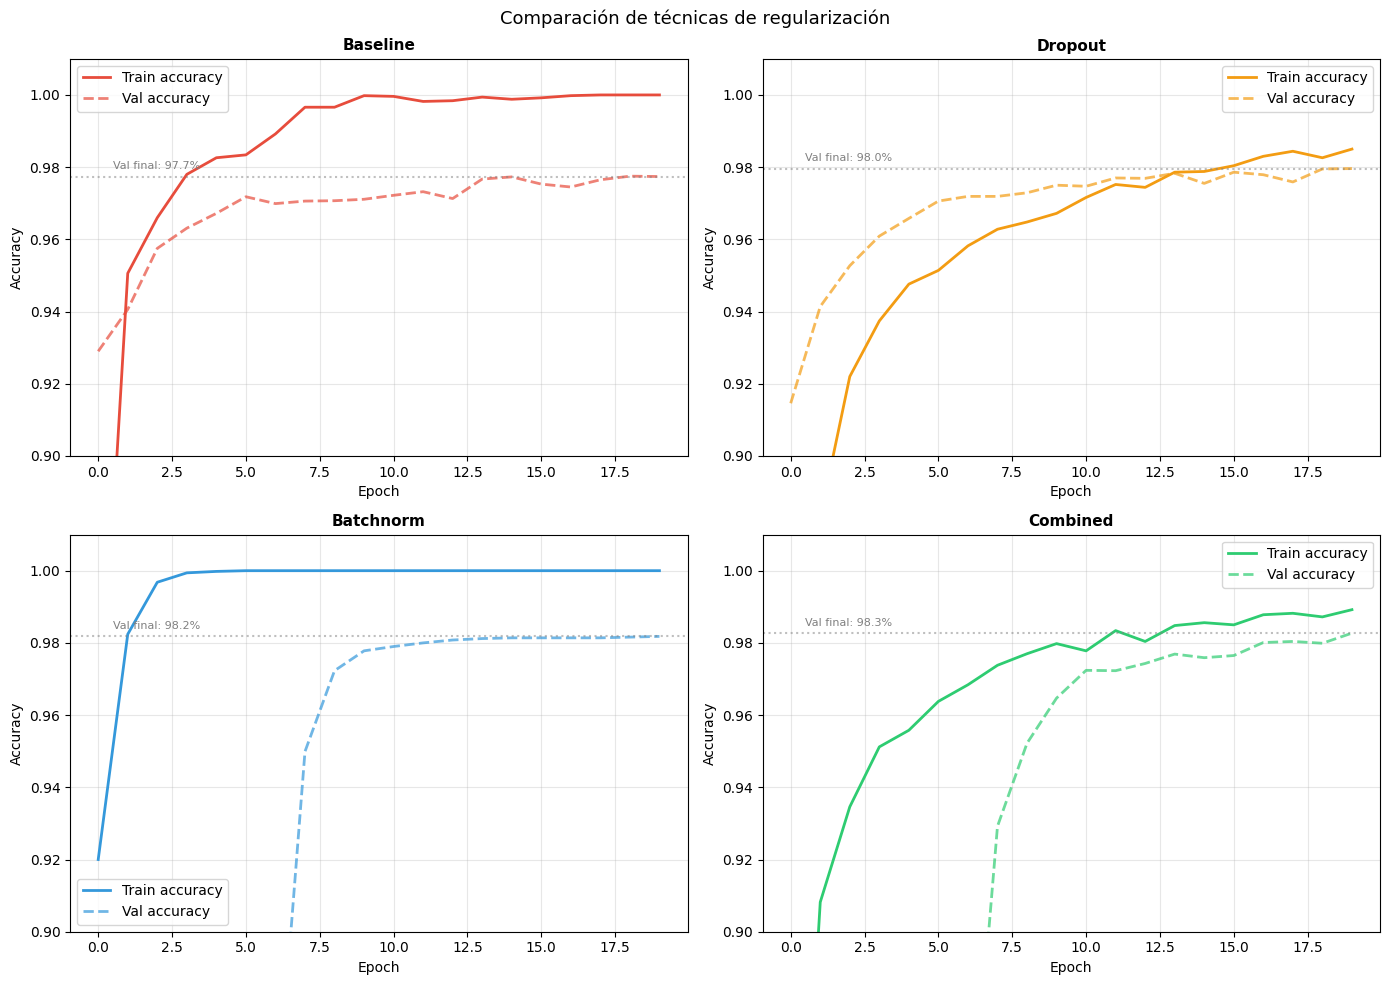

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparación de técnicas de regularización', fontsize=13)

colores = {
    'baseline':  '#e74c3c',
    'dropout':   '#f39c12',
    'batchnorm': '#3498db',
    'combined':  '#2ecc71'
}

axes_flat = axes.flatten()

for i, (name, history) in enumerate(histories.items()):
    ax = axes_flat[i]

    ax.plot(history.history['accuracy'],
            label='Train accuracy', linewidth=2, color=colores[name])
    ax.plot(history.history['val_accuracy'],
            label='Val accuracy', linewidth=2, linestyle='--', color=colores[name],
            alpha=0.7)

    # Marcar val_accuracy final
    final_val = history.history['val_accuracy'][-1]
    ax.axhline(y=final_val, color='gray', linestyle=':', alpha=0.5)
    ax.text(0.5, final_val + 0.002, f'Val final: {final_val*100:.1f}%',
            fontsize=8, color='gray')

    ax.set_title(f'{name.capitalize()}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_ylim(0.90, 1.01)

plt.tight_layout()
plt.savefig('../figures/06_curvas_comparacion.png', dpi=120, bbox_inches='tight')
plt.show()

In [10]:
"""
## 6. Evaluación final en test set

Las curvas nos dieron intuición visual. Ahora vamos a cuantificar
el efecto de cada técnica evaluando los cuatro modelos sobre
el mismo test set.

La métrica que más importa es siempre el test set — es la única evaluación sobre datos que el modelo nunca vio en ningún momento del proceso de entrenamiento.
"""

'\n## 6. Evaluación final en test set\n\nLas curvas nos dieron intuición visual. Ahora vamos a cuantificar\nel efecto de cada técnica evaluando los cuatro modelos sobre\nel mismo test set.\n\nLa métrica que más importa es siempre el test set — es la única evaluación sobre datos que el modelo nunca vio en ningún momento del proceso de entrenamiento.\n'

Modelo            Test Accuracy       Test Loss
baseline                  97.8%          0.0908
dropout                   97.7%          0.0710
batchnorm                 98.2%          0.0587
combined                  98.0%          0.0564


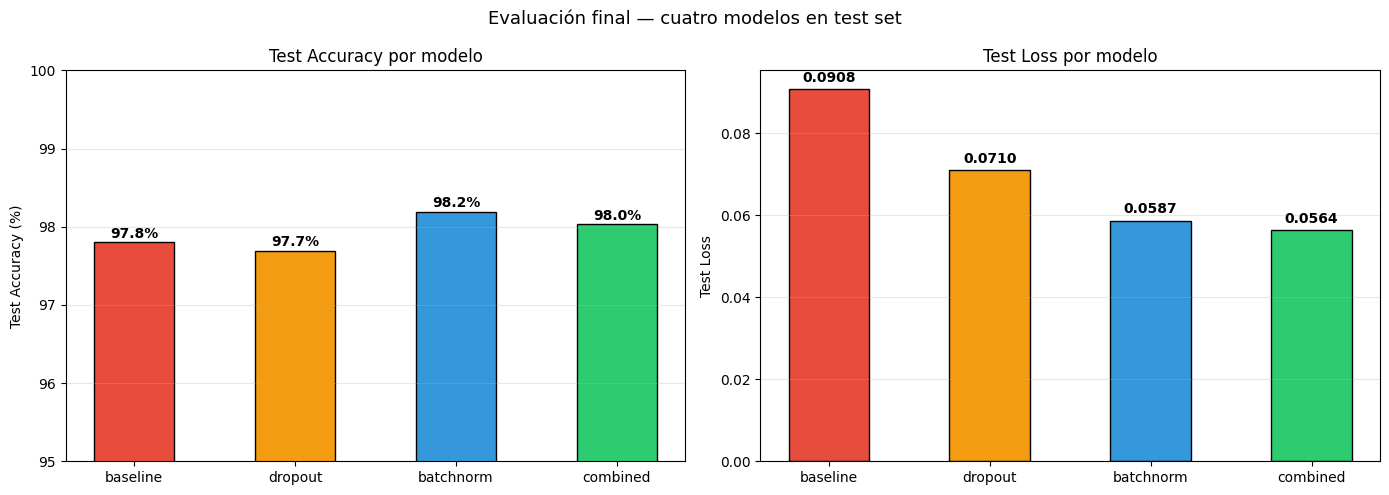

In [11]:
# Evaluar los cuatro modelos en test set
resultados = {}

for name, model in models.items():
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    resultados[name] = {'accuracy': acc, 'loss': loss}

# Tabla comparativa
print("="*60)
print(f"{'Modelo':<15} {'Test Accuracy':>15} {'Test Loss':>15}")
print("="*60)
for name, res in resultados.items():
    print(f"{name:<15} {res['accuracy']*100:>14.1f}% {res['loss']:>15.4f}")
print("="*60)

# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evaluación final — cuatro modelos en test set', fontsize=13)

nombres   = list(resultados.keys())
accuracys = [resultados[n]['accuracy'] * 100 for n in nombres]
losses    = [resultados[n]['loss'] for n in nombres]
colores   = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']

# Accuracy
bars = axes[0].bar(nombres, accuracys, color=colores, edgecolor='black', width=0.5)
axes[0].set_ylim(95, 100)
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Test Accuracy por modelo')
axes[0].grid(axis='y', alpha=0.3)
for bar, acc in zip(bars, accuracys):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{acc:.1f}%', ha='center', va='bottom',
                 fontsize=10, fontweight='bold')

# Loss
bars2 = axes[1].bar(nombres, losses, color=colores, edgecolor='black', width=0.5)
axes[1].set_ylabel('Test Loss')
axes[1].set_title('Test Loss por modelo')
axes[1].grid(axis='y', alpha=0.3)
for bar, loss in zip(bars2, losses):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{loss:.4f}', ha='center', va='bottom',
                 fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/06_comparacion_final.png', dpi=120, bbox_inches='tight')
plt.show()

In [12]:
"""
## Resumen del notebook

| Concepto | Lo que aprendimos |
|---|---|
| ""Dropout"" | Apaga neuronas aleatoriamente durante el entrenamiento |
| ""Batch Normalization"" | Normaliza activaciones para estabilizar el entrenamiento |
| ""Dropout rate"" | 0.25 después de Conv, 0.5 después de Dense |
| ""Posición de BN"" | Después de Conv/Dense, antes de la activación |
| ""Loss vs Accuracy"" | La loss es más sensible para detectar mejoras de regularización |
| ""Modelo combinado"" | BN + Dropout juntos dan la mejor loss y más robustez |
---
## ¿Qué sigue?
En el ""notebook 07"" vamos a estudiar en profundidad el overfitting
y el underfitting — cómo detectarlos, diagnosticarlos y corregirlos
usando todas las herramientas que aprendimos hasta ahora.
"""

'\n## Resumen del notebook\n\n| Concepto | Lo que aprendimos |\n|---|---|\n| ""Dropout"" | Apaga neuronas aleatoriamente durante el entrenamiento |\n| ""Batch Normalization"" | Normaliza activaciones para estabilizar el entrenamiento |\n| ""Dropout rate"" | 0.25 después de Conv, 0.5 después de Dense |\n| ""Posición de BN"" | Después de Conv/Dense, antes de la activación |\n| ""Loss vs Accuracy"" | La loss es más sensible para detectar mejoras de regularización |\n| ""Modelo combinado"" | BN + Dropout juntos dan la mejor loss y más robustez |\n---\n## ¿Qué sigue?\nEn el ""notebook 07"" vamos a estudiar en profundidad el overfitting\ny el underfitting — cómo detectarlos, diagnosticarlos y corregirlos\nusando todas las herramientas que aprendimos hasta ahora.\n'